# BitCoin Analysis

In [ ]:
import pandas as pd 
from ydata_profiling import ProfileReport
import  numpy as np 
import  matplotlib.pyplot as plt 
import  seaborn as sns 

In [8]:
df =pd.read_csv(r"D:\learn-python-for-data-science\DatasetFiles\BitCoin/bitcoin_price_Training - Training.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Market Cap
0,"Jul 31, 2017",2763.24,2889.62,2720.61,2875.34,"860,575,000","45,535,800,000"
1,"Jul 30, 2017",2724.39,2758.53,2644.85,2757.18,"705,943,000","44,890,700,000"
2,"Jul 29, 2017",2807.02,2808.76,2692.80,2726.45,"803,746,000","46,246,700,000"
3,"Jul 28, 2017",2679.73,2897.45,2679.73,2809.01,"1,380,100,000","44,144,400,000"
4,"Jul 27, 2017",2538.71,2693.32,2529.34,2671.78,"789,104,000","41,816,500,000"


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1556 non-null   object 
 1   Open        1556 non-null   float64
 2   High        1556 non-null   float64
 3   Low         1556 non-null   float64
 4   Close       1556 non-null   float64
 5   Volume      1556 non-null   object 
 6   Market Cap  1556 non-null   object 
dtypes: float64(4), object(3)
memory usage: 85.2+ KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1556.0,582.625328,523.137312,68.50,254.2875,438.600,662.4375,2953.22
High,1556.0,597.992847,542.992855,74.56,260.3275,447.560,674.5250,2999.91
Low,1556.0,567.851446,505.877401,65.53,248.8350,430.570,646.7350,2840.53
Close,1556.0,584.239396,525.904442,68.43,254.3200,438.855,663.4025,2958.11


In [ ]:
df["Date"] = df["Date"].astype('datetime64[ns]')


In [16]:
df["Date"]

0      2017-07-31
1      2017-07-30
2      2017-07-29
3      2017-07-28
4      2017-07-27
          ...    
1551   2013-05-02
1552   2013-05-01
1553   2013-04-30
1554   2013-04-29
1555   2013-04-28
Name: Date, Length: 1556, dtype: datetime64[ns]

In [17]:
df["Date"].min()

Timestamp('2013-04-28 00:00:00')

In [18]:
df["Date"].max()

Timestamp('2017-07-31 00:00:00')

In [ ]:
df.duplicated().sum() # Thie  have no duplicate values 

np.int64(0)

In [22]:
df.isnull().sum() # Their have no null values

Date          0
Open          0
High          0
Low           0
Close         0
Volume        0
Market Cap    0
dtype: int64

In [26]:
data = df.sort_index(ascending=False).reset_index()
data

,index,Date,Open,High,Low,Close,Volume,Market Cap
0,1555,2013-04-28,135.30,135.98,132.10,134.21,-,"1,500,520,000"
1,1554,2013-04-29,134.44,147.49,134.00,144.54,-,"1,491,160,000"
2,1553,2013-04-30,144.00,146.93,134.05,139.00,-,"1,597,780,000"
3,1552,2013-05-01,139.00,139.89,107.72,116.99,-,"1,542,820,000"
4,1551,2013-05-02,116.38,125.60,92.28,105.21,-,"1,292,190,000"
...,...,...,...,...,...,...,...,...
1551,4,2017-07-27,2538.71,2693.32,2529.34,2671.78,"789,104,000","41,816,500,000"
1552,3,2017-07-28,2679.73,2897.45,2679.73,2809.01,"1,380,100,000","44,144,400,000"
1553,2,2017-07-29,2807.02,2808.76,2692.80,2726.45,"803,746,000","46,246,700,000"
1554,1,2017-07-30,2724.39,2758.53,2644.85,2757.18,"705,943,000","44,890,700,000"


In [ ]:
data.drop('index',axis= 1 , inplace=True)  
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap'], dtype='object')

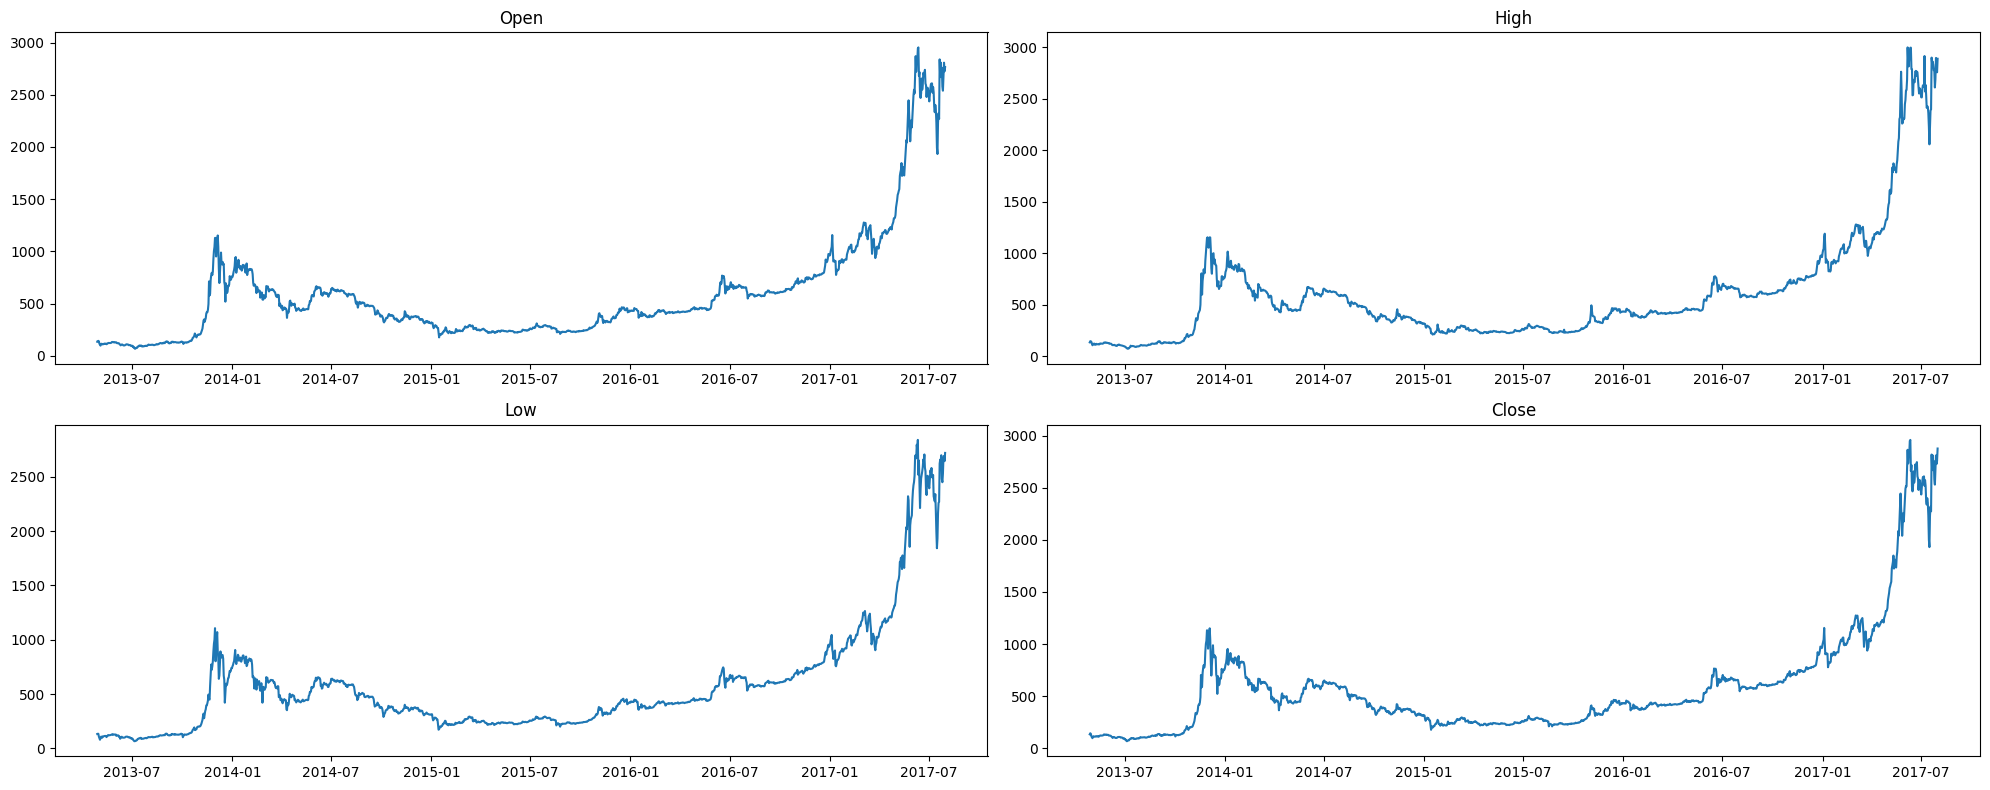

In [40]:
plt.figure(figsize=(20, 8))  # Optional: Make it bigger

for index, col in enumerate(['Open', 'High', 'Low', 'Close'], 1):
    plt.subplot(2, 2, index) 
    plt.plot(data["Date"], data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [41]:
#Plotly setup 

import chart_studio.plotly as py
import plotly.graph_objs as go 
import plotly.express as px 
#To use graph  in offline mode 
from plotly.offline import download_plotlyjs , init_notebook_mode ,plot , iplot 

In [43]:
init_notebook_mode(connected=True)

In [71]:

# data= data.head(20)
trace = go.Candlestick(
    x=data["Date"],
    open=data["Open"],
    high=data["High"],
    low=data["Low"],
    close=data["Close"]
)

candle_data = [trace]
layout = go.Layout(
    title='Candlestick Chart',
    xaxis=dict(title='Date', rangeslider=dict(visible=False)),
    yaxis=dict(title='Price')
)



In [73]:
# plt.figure(figsize=(200,1))
fig = go.Figure(data=candle_data, layout=layout)
fig.update_layout( xaxis_rangeslider_visible = False)
fig.show()

# Analyse Closing price of stock

In [ ]:

data.set_index("Date" , inplace=True)


In [89]:
data

,Open,High,Low,Close,Volume,Market Cap
Date,,,,,,
2017-07-31,2763.24,2889.62,2720.61,2875.34,"860,575,000","45,535,800,000"
2017-07-30,2724.39,2758.53,2644.85,2757.18,"705,943,000","44,890,700,000"
2017-07-29,2807.02,2808.76,2692.80,2726.45,"803,746,000","46,246,700,000"
2017-07-28,2679.73,2897.45,2679.73,2809.01,"1,380,100,000","44,144,400,000"
2017-07-27,2538.71,2693.32,2529.34,2671.78,"789,104,000","41,816,500,000"
...,...,...,...,...,...,...
2013-05-02,116.38,125.60,92.28,105.21,-,"1,292,190,000"
2013-05-01,139.00,139.89,107.72,116.99,-,"1,542,820,000"
2013-04-30,144.00,146.93,134.05,139.00,-,"1,597,780,000"


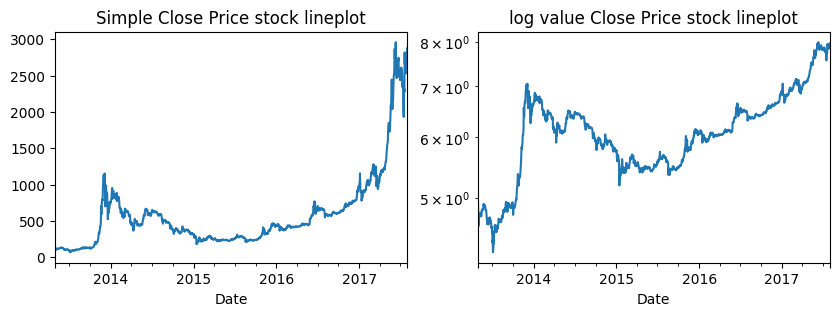

In [97]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
data["Close"].plot() 
plt.title("Simple Close Price stock lineplot")

plt.subplot(1,2,2)
np.log1p(data["Close"]).plot()
plt.title("log value Close Price stock lineplot")
plt.yscale("log")


# Analyse Closing price on Yearly , Quaterly , Monthly Basis 

In [103]:
data["Close"].resample('Y').mean()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23088\2585058087.py:1: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



Date
2013-12-31     257.474476
2014-12-31     527.236658
2015-12-31     272.453260
2016-12-31     568.492131
2017-12-31    1628.622123
Freq: YE-DEC, Name: Close, dtype: float64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23088\1441917073.py:1: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



<Axes: xlabel='Date'>

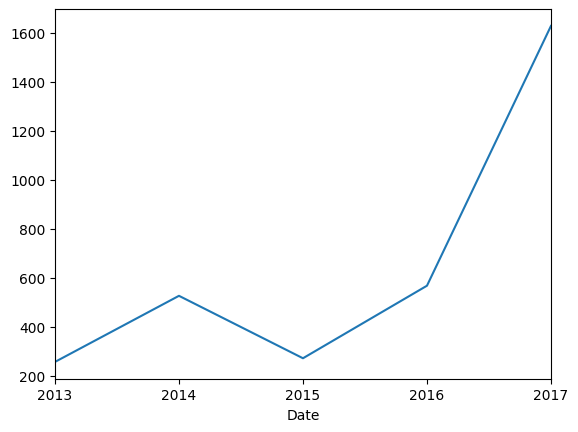

In [102]:
data["Close"].resample('Y').mean().plot()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23088\1276924470.py:1: FutureWarning:

'Q' is deprecated and will be removed in a future version, please use 'QE' instead.



<Axes: xlabel='Date'>

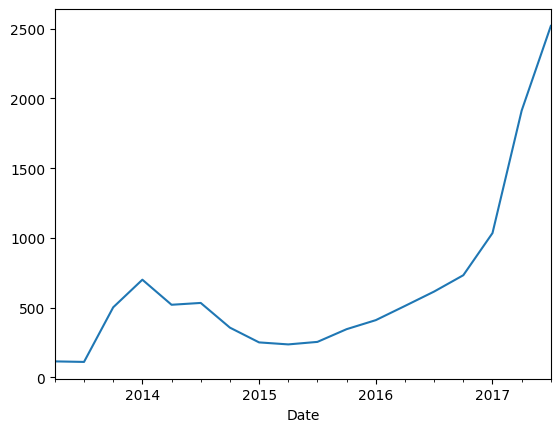

In [104]:
data["Close"].resample('Q').mean().plot()


# Analysing daily change in closing price of stock

In [127]:
data

,Open,High,Low,Close,Volume,Market Cap,percent_chng,month_year
Date,,,,,,,,
2017-07-31,2763.24,2889.62,2720.61,2875.34,"860,575,000","45,535,800,000",NaN,2017-07
2017-07-30,2724.39,2758.53,2644.85,2757.18,"705,943,000","44,890,700,000",-4.109427,2017-07
2017-07-29,2807.02,2808.76,2692.80,2726.45,"803,746,000","46,246,700,000",-1.114545,2017-07
2017-07-28,2679.73,2897.45,2679.73,2809.01,"1,380,100,000","44,144,400,000",3.028113,2017-07
2017-07-27,2538.71,2693.32,2529.34,2671.78,"789,104,000","41,816,500,000",-4.885351,2017-07
...,...,...,...,...,...,...,...,...
2013-05-02,116.38,125.60,92.28,105.21,-,"1,292,190,000",7.631714,2013-05
2013-05-01,139.00,139.89,107.72,116.99,-,"1,542,820,000",11.196654,2013-05
2013-04-30,144.00,146.93,134.05,139.00,-,"1,597,780,000",18.813574,2013-04


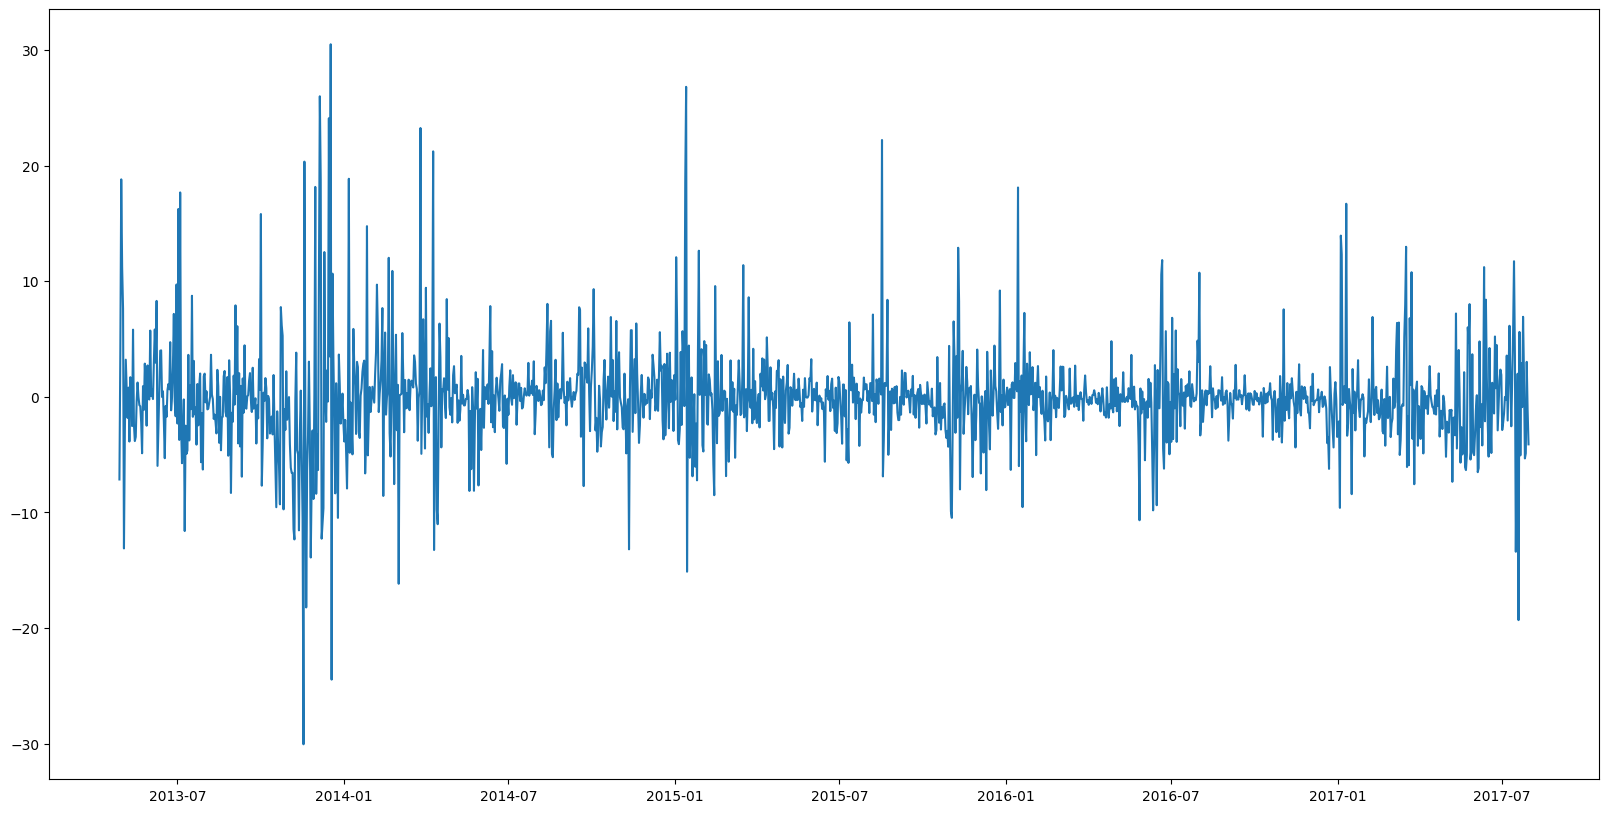

In [126]:
plt.figure(figsize=(20,10))
data["percent_chng"] = data["Close"].pct_change()*100
plt.plot(data.index , data["percent_chng"])

In [141]:

import plotly.express as px
plt.figure(figsize=(20,2))
fig = px.line(data, y="percent_chng", title="Percent Change Over Time")
fig.show()


<Figure size 2000x200 with 0 Axes>